### Overview

PCA plots of sample segregation in all datasets using word2vec-based gene expression representations

In [1]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn import metrics
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
seed = 42
np.random.seed(seed)
random.seed(seed)

#### 1. Import and prepare data

In [3]:
# import PAM50 genes
pam50 = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/pam50gene_list_csv.csv", header=0)

In [4]:
# import tpm count files
train = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_hiseq_train_test_sets/train_test_80_20/SCANB_HiSeq_pam50gene_tpm_counts_subtype_train_80.csv", 
                          header=0, index_col=0)
scanb_hiseq_test = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_hiseq_train_test_sets/train_test_80_20/SCANB_HiSeq_pam50gene_tpm_counts_subtype_test_20.csv", 
                          header=0, index_col=0)
scanb_nextseq_test = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_cleaned_data/pam50genes_tpm_counts_subtype_scanb_nextseq.csv", 
                          header=0, index_col=0)
tcga_test = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/TCGA_BRCA/tcga_brca_cleaned_data/pam50genes_tpm_counts_subtype_tcga_brca.csv", 
                       header=0, index_col=0)

In [5]:
# check dimension
print(train.shape)
print(scanb_hiseq_test.shape)
print(scanb_nextseq_test.shape)
print(tcga_test.shape)

(2204, 52)
(551, 52)
(276, 51)
(1031, 51)


In [6]:
# check whether the first 50 column names (PAM50 gene ensembl IDs) match
print(train.columns[0:50].equals(scanb_hiseq_test.columns[0:50]))
print(train.columns[0:50].equals(scanb_nextseq_test.columns[0:50]))
print(train.columns[0:50].equals(tcga_test.columns[0:50]))

True
True
True


In [7]:
# check whether the ensemble id column order match with that of in the pam50 df
train.columns[0:50].tolist() == pam50['ensembl_gene_id'].tolist()

True

In [8]:
# extract counts
train_counts = train.iloc[:, 0:50]
scanb_hiseq_test_counts = scanb_hiseq_test.iloc[:, 0:50]
scanb_nextseq_test_counts = scanb_nextseq_test.iloc[:, 0:50]
tcga_test_counts = tcga_test.iloc[:, 0:50]

#### 2. Generate word2vec embeddings

In [9]:
# function to rank gene names
def get_top_genes(row):
    return row.sort_values(ascending=False).index.to_list()

In [10]:
# function to get average embedding
# need to average the word embeddings because it creates a fixed-length single vector representation for the entire sequence
# useful for machine learning models which needs a single input vector for each sample
# Word2vec creates (m,n) embedding vector for each sequence (m: number of words in the sequence, n: embedding vector size)
# each word has an embedding of shape (vector size,)
# the average of the embeddings have to be computed column wise to maintain the shape of embedding vector size
# averaging the mean row-wise is incorrect, because it reduces the embedding of an entire word into a single value.
def get_average_vector(sequence, model):
    vectors = [model.wv[word] for word in sequence if word in model.wv]
    # return a zero vector if no valid words
    if len(vectors) == 0:
        return np.zeros(model.vector_size)  
    return np.mean(vectors, axis=0)


In [11]:
# rank the gene names for all the samples
# scan-b hiseq training set
train_ranked_geneList = train_counts.apply(lambda row: get_top_genes(row), axis=1)
train_ranked_geneList = pd.DataFrame(train_ranked_geneList , index=train_counts.index, columns=['ranked_gene_list'])

# scan-b hiseq test set
scanb_hiseq_test_ranked_geneList = scanb_hiseq_test_counts.apply(lambda row: get_top_genes(row), axis=1)
scanb_hiseq_test_ranked_geneList = pd.DataFrame(scanb_hiseq_test_ranked_geneList , index=scanb_hiseq_test_counts.index, columns=['ranked_gene_list'])

# scan-b nextseq test set
scanb_nextseq_test_ranked_geneList = scanb_nextseq_test_counts.apply(lambda row: get_top_genes(row), axis=1)
scanb_nextseq_test_ranked_geneList = pd.DataFrame(scanb_nextseq_test_ranked_geneList , index=scanb_nextseq_test_counts.index, columns=['ranked_gene_list'])

#tcga brca test set
tcga_test_ranked_geneList = tcga_test_counts.apply(lambda row: get_top_genes(row), axis=1)
tcga_test_ranked_geneList = pd.DataFrame(tcga_test_ranked_geneList , index=tcga_test_counts.index, columns=['ranked_gene_list'])

In [12]:
print(train_ranked_geneList.shape)
print(scanb_hiseq_test_ranked_geneList.shape)
print(scanb_nextseq_test_ranked_geneList.shape)
print(tcga_test_ranked_geneList.shape)

(2204, 1)
(551, 1)
(276, 1)
(1031, 1)


In [13]:
# train word2vec using the svm-optimized parameters
w2v_model_svm = Word2Vec(train_ranked_geneList['ranked_gene_list'], vector_size=600, sg=1, alpha=0.01, window=5, epochs=5,
                         seed=seed, workers=1)

In [14]:
# Convert each sequence of each sample to average word embedding vector and save it as a 2d array
train_vect = np.array([get_average_vector(seq, w2v_model_svm) for seq in train_ranked_geneList['ranked_gene_list']])
scanb_hiseq_test_vect = np.array([get_average_vector(seq, w2v_model_svm) for seq in scanb_hiseq_test_ranked_geneList['ranked_gene_list']])
scanb_nextseq_test_vect = np.array([get_average_vector(seq, w2v_model_svm) for seq in scanb_nextseq_test_ranked_geneList['ranked_gene_list']])
tcga_test_vect = np.array([get_average_vector(seq, w2v_model_svm) for seq in tcga_test_ranked_geneList['ranked_gene_list']])

In [15]:
# standardization of the embedding vectors
scaler = StandardScaler()
train_vect_scaled = scaler.fit_transform(train_vect)
scanb_hiseq_test_vect_scaled = scaler.transform(scanb_hiseq_test_vect)
scanb_nextseq_test_vect_scaled = scaler.transform(scanb_nextseq_test_vect)
tcga_test_vect_scaled = scaler.transform(tcga_test_vect)

print(train_vect_scaled.shape)
print(scanb_hiseq_test_vect_scaled.shape)
print(scanb_nextseq_test_vect_scaled.shape)
print(tcga_test_vect_scaled.shape)

(2204, 600)
(551, 600)
(276, 600)
(1031, 600)


#### 3. Visualize sample segregation using PCA

In [16]:
# pca transformation
pca = PCA(n_components=2, random_state=seed)

# scanb hiseq training set
pcaComponents_train = pca.fit_transform(train_vect_scaled)
pcaComponents_train = pd.DataFrame(pcaComponents_train, columns=["PC1", "PC2"], index=train_counts.index)
print(pcaComponents_train.shape)

# scanb hiseq test set
pcaComponents_scanbhiseq_test = pca.transform(scanb_hiseq_test_vect_scaled)
pcaComponents_scanbhiseq_test = pd.DataFrame(pcaComponents_scanbhiseq_test, columns=["PC1", "PC2"], index=scanb_hiseq_test_counts.index)
print(pcaComponents_scanbhiseq_test.shape)

# scanb nextseq test set
pcaComponents_scanbnextseq_test = pca.transform(scanb_nextseq_test_vect_scaled)
pcaComponents_scanbnextseq_test = pd.DataFrame(pcaComponents_scanbnextseq_test, columns=["PC1", "PC2"], index=scanb_nextseq_test_counts.index)
print(pcaComponents_scanbnextseq_test.shape)

# tcga-brca test set
pcaComponents_tcga_test = pca.transform(tcga_test_vect_scaled)
pcaComponents_tcga_test = pd.DataFrame(pcaComponents_tcga_test, columns=["PC1", "PC2"], index=tcga_test_counts.index)
print(pcaComponents_tcga_test.shape)

(2204, 2)
(551, 2)
(276, 2)
(1031, 2)


In [22]:
# check if the indices match
print(train.index.equals(pcaComponents_train.index))
print(scanb_hiseq_test.index.equals(pcaComponents_scanbhiseq_test.index))
print(scanb_nextseq_test.index.equals(pcaComponents_scanbnextseq_test.index))
print(tcga_test.index.equals(pcaComponents_tcga_test.index))

True
True
True
True


In [23]:
# join pca components and subtype
pcaComponents_train_subtype = pcaComponents_train.join(train.loc[:, ['subtype']])
pcaComponents_scanbhiseq_test_subtype = pcaComponents_scanbhiseq_test.join(scanb_hiseq_test.loc[:, ['subtype']])
pcaComponents_scanbnextseq_test_subtype = pcaComponents_scanbnextseq_test.join(scanb_nextseq_test.loc[:, ['subtype']])
pcaComponents_tcga_test_subtype = pcaComponents_tcga_test.join(tcga_test.loc[:, ['subtype']])

In [24]:
# replace Her2 by HER2
pcaComponents_train_subtype['subtype'] = pcaComponents_train_subtype['subtype'].replace({'Her2':'HER2'})
pcaComponents_scanbhiseq_test_subtype['subtype'] = pcaComponents_scanbhiseq_test_subtype['subtype'].replace({'Her2':'HER2'})
pcaComponents_scanbnextseq_test_subtype['subtype'] = pcaComponents_scanbnextseq_test_subtype['subtype'].replace({'Her2':'HER2'})
pcaComponents_tcga_test_subtype['subtype'] = pcaComponents_tcga_test_subtype['subtype'].replace({'Her2':'HER2'})

In [26]:
# define colors for subtype to be used in pca plots
custom_palette = {
    'Basal': '#DA70D6',  
    'HER2': '#00BFFF',  
    'LumA': '#50C878',  
    'LumB': '#FF033E',   
}

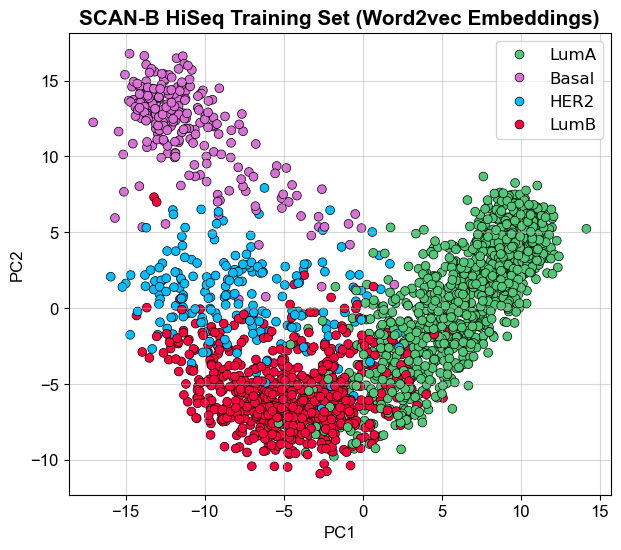

In [27]:
# pca plot of scanb hiseq training set
plt.figure(figsize=(7, 6))
sns.scatterplot(x=pcaComponents_train_subtype["PC1"], 
                y=pcaComponents_train_subtype["PC2"], 
                hue=pcaComponents_train_subtype["subtype"],
                palette=custom_palette, 
                s=40, alpha=1, edgecolor='black', linewidth = 0.5)
plt.xlabel("PC1", fontsize=12, fontfamily='Arial')
plt.ylabel("PC2", fontsize=12, fontfamily='Arial')
plt.title("SCAN-B HiSeq Training Set (Word2vec Embeddings)", fontsize=15, fontfamily='Arial', weight='bold')
plt.legend(loc="upper right", ncol=1, fontsize=12)
# plt.xlim(-18, 15)
# plt.ylim(-12.5, 18)
plt.xticks(fontsize=12, fontfamily='Arial')  
plt.yticks(fontsize=12, fontfamily='Arial') 
plt.grid(alpha=0.5)
# plt.savefig("scanb_hiseq_train_pca_word_embeddings.png", dpi=300, bbox_inches="tight")
plt.show()

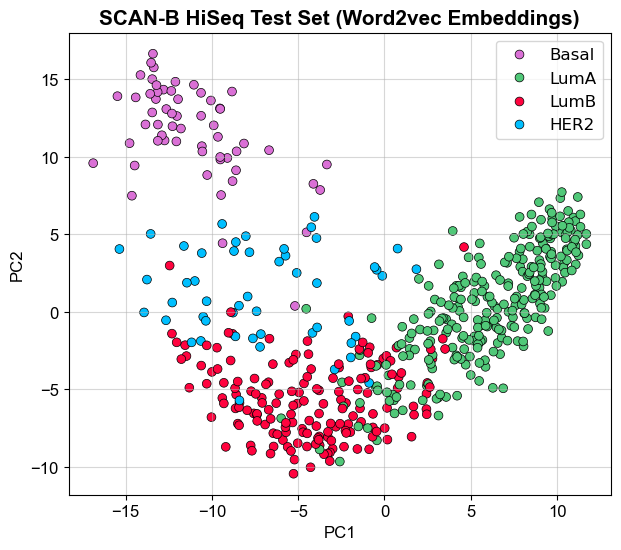

In [23]:
# pca plot of scanb hiseq test set
plt.figure(figsize=(7, 6))
sns.scatterplot(x=pcaComponents_scanbhiseq_test_subtype["PC1"], 
                y=pcaComponents_scanbhiseq_test_subtype["PC2"], 
                hue=pcaComponents_scanbhiseq_test_subtype["subtype"],
                palette=custom_palette, 
                s=40, alpha=1, edgecolor='black', linewidth = 0.5)
plt.xlabel("PC1", fontsize=12, fontfamily='Arial')
plt.ylabel("PC2", fontsize=12, fontfamily='Arial')
plt.title("SCAN-B HiSeq Test Set (Word2vec Embeddings)", fontsize=15, fontfamily='Arial', weight='bold')
plt.legend(loc="upper right", ncol=1, fontsize=12)
# plt.xlim(-18, 15)
# plt.ylim(-12.5, 18.5)
plt.xticks(fontsize=12, fontfamily='Arial')  
plt.yticks(fontsize=12, fontfamily='Arial') 
plt.grid(alpha=0.5)
plt.savefig("scanb_hiseq_test_pca_word_embeddings.png", dpi=300, bbox_inches="tight")
plt.show()

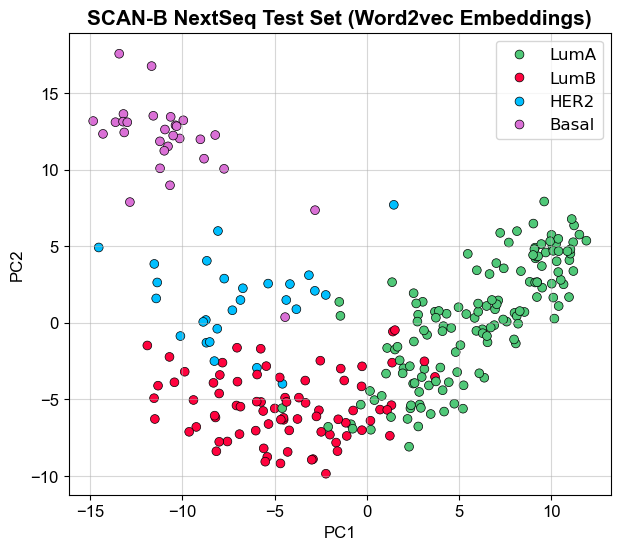

In [28]:
# pca plot of scanb nextseq test set
plt.figure(figsize=(7, 6))
sns.scatterplot(x=pcaComponents_scanbnextseq_test_subtype["PC1"], 
                y=pcaComponents_scanbnextseq_test_subtype["PC2"], 
                hue=pcaComponents_scanbnextseq_test_subtype["subtype"],
                palette=custom_palette, 
                s=40, alpha=1, edgecolor='black', linewidth = 0.5)
plt.xlabel("PC1", fontsize=12, fontfamily='Arial')
plt.ylabel("PC2", fontsize=12, fontfamily='Arial')
plt.title("SCAN-B NextSeq Test Set (Word2vec Embeddings)", fontsize=15, fontfamily='Arial', weight='bold')
plt.legend(loc="upper right", ncol=1, fontsize=12)
# plt.xlim(-18, 15)
# plt.ylim(-12.5, 18.5)
plt.xticks(fontsize=12, fontfamily='Arial')  
plt.yticks(fontsize=12, fontfamily='Arial') 
plt.grid(alpha=0.5)
# plt.savefig("scanb_nextseq_test_pca_word_embeddings.png", dpi=300, bbox_inches="tight")
plt.show()

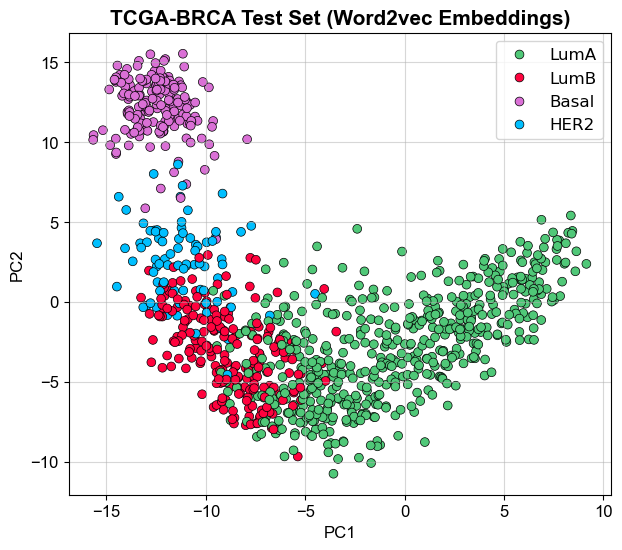

In [29]:
# pca plot of tcga test set
plt.figure(figsize=(7, 6))
sns.scatterplot(x=pcaComponents_tcga_test_subtype["PC1"], 
                y=pcaComponents_tcga_test_subtype["PC2"], 
                hue=pcaComponents_tcga_test_subtype["subtype"],
                palette=custom_palette, 
                s=40, alpha=1, edgecolor='black', linewidth = 0.5)
plt.xlabel("PC1", fontsize=12, fontfamily='Arial')
plt.ylabel("PC2", fontsize=12, fontfamily='Arial')
plt.title("TCGA-BRCA Test Set (Word2vec Embeddings)", fontsize=15, fontfamily='Arial', weight='bold')
plt.legend(loc="upper right", ncol=1, fontsize=12)
# plt.xlim(-18, 15)
# plt.ylim(-12.5, 18.5)
plt.xticks(fontsize=12, fontfamily='Arial')  
plt.yticks(fontsize=12, fontfamily='Arial') 
plt.grid(alpha=0.5)
# plt.savefig("tcga_test_pca_word_embeddings.png", dpi=300, bbox_inches="tight")
plt.show()